## Testing the Gadget for the $^{20} \text{O}$ using the interaction encoding

### Imports

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import (
    EffectiveInteractionOptimizer,
    EffectiveInteractionOptimizerTunableSelfEnergy,
    EffectiveInteractionOptimizer2ndVersion,
)
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import (
    get_twobody_nuclearshell_model,
    SingleParticleState,
)
import numpy as np
import torch
from typing import Dict
import scipy
from NSMFermions.qml_models import AdaptVQEFermiHubbard
from NSMFermions.qml_utils.train import Fit
from NSMFermions.qml_utils.utils import configuration
from scipy.sparse.linalg import eigsh, expm_multiply
from tqdm import trange
import matplotlib.pyplot as plt
from NSMFermions.utils_quasiparticle_approximation import (
    QuasiParticlesConverter,
    HardcoreBosonsBasis,
    QuasiParticlesConverterOnlynnpp,
)
from src.utils import (
    generate_particleconservation_basis,
    array_to_qutip,
    build_total_hamiltonian,
    build_effective_hamiltonian,
    compute_particle_number,
)

/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


### Load the coupling of the Quasiparticle Hamiltonian

We upload the $g^{(1)}_{AB}$ couplings from the numpy dictionary, we also fix the number of Qubit for the system that we are considering. Since the $^{6}\text{Be}$ involves only one active quasiparticle proton, we don't need any two-body interaction

In [62]:
import pickle

with open("data/doci_couplings_be2.pkl", "rb") as f:
    g, v, eps, E_core, meta = pickle.load(f)

n_qubits = 6

g_onebody = g
g_twobody = v

print(g_twobody)
diagonal_terms = eps
energy_shift = E_core
print(diagonal_terms)

g_matrix = np.zeros((n_qubits, n_qubits))
for a in range(n_qubits):
    for b in range(a + 1, n_qubits):
        g_matrix[a, b] = g_onebody[(a, b)]
        g_matrix[b, a] = g_onebody[(a, b)]
# get the computational basis of the space
print(g_matrix)
basis = computational_basis(n_qubits)

{(0, 1): np.float64(1.0029952848201749), (0, 2): np.float64(1.144841197672774), (0, 3): np.float64(1.1629788635519003), (0, 4): np.float64(1.1629788635519005), (0, 5): np.float64(1.1906263317877133), (1, 2): np.float64(1.048339849126519), (1, 3): np.float64(1.091193834026003), (1, 4): np.float64(1.0911938340260032), (1, 5): np.float64(1.101285838681184), (2, 3): np.float64(1.154686689553313), (2, 4): np.float64(1.1546866895533134), (2, 5): np.float64(1.1752179560833196), (3, 4): np.float64(1.155016498441354), (3, 5): np.float64(1.066886763283697), (4, 5): np.float64(1.1388475207517916)}
[-2.02109543 -1.66457897 -1.5856448  -1.59240743 -1.59240743 -1.416038  ]
[[0.         0.07908971 0.04979058 0.05142806 0.05142806 0.0335504 ]
 [0.07908971 0.         0.08514541 0.0359875  0.0359875  0.04853422]
 [0.04979058 0.08514541 0.         0.01463656 0.01463656 0.01504358]
 [0.05142806 0.0359875  0.01463656 0.         0.01247322 0.10198621]
 [0.05142806 0.0359875  0.01463656 0.01247322 0.        

#### Study the Quasiparticle Hamiltonian with the Hardcore Boson Basis

In [63]:
nparticles_a = 2
nparticles_b = 0

particle_conserved_basis = generate_particleconservation_basis(
    size_a=n_qubits, size_b=0, nparticles_a=nparticles_a, nparticles_b=nparticles_b
)

print(particle_conserved_basis)

# initialize the class in the number sector of the quasiparticle space (see NSMFermion library)
HBB = HardcoreBosonsBasis(basis=particle_conserved_basis)
quasiparticle_hamiltonian_particle_conserved = 0.0
for key, value in g_onebody.items():
    idx_a, idx_b = key
    if idx_a != idx_b:
        quasiparticle_hamiltonian_particle_conserved += value * HBB.adag_a_matrix(
            idx_a, idx_b
        )
        quasiparticle_hamiltonian_particle_conserved += value * HBB.adag_a_matrix(
            idx_b, idx_a
        )

for idx_a in range(n_qubits):
    quasiparticle_hamiltonian_particle_conserved += diagonal_terms[
        idx_a
    ] * HBB.adag_a_matrix(idx_a, idx_a)

for key, value in g_twobody.items():
    idx_a, idx_b = key
    print(idx_a, idx_b, value)
    quasiparticle_hamiltonian_particle_conserved += (
        0.5 * value * HBB.adag_adag_a_a_matrix(idx_a, idx_b, idx_a, idx_b)
    )
    quasiparticle_hamiltonian_particle_conserved += (
        0.5 * value * HBB.adag_adag_a_a_matrix(idx_b, idx_a, idx_b, idx_a)
    )
print(quasiparticle_hamiltonian_particle_conserved)
value, eigenstates_particle_conserved = np.linalg.eigh(
    quasiparticle_hamiltonian_particle_conserved.todense()
)

max_eigval_idx = np.argmax(value)
print(max_eigval_idx)

print(value + energy_shift)

[[1 1 0 0 0 0]
 [1 0 1 0 0 0]
 [1 0 0 1 0 0]
 [1 0 0 0 1 0]
 [1 0 0 0 0 1]
 [0 1 1 0 0 0]
 [0 1 0 1 0 0]
 [0 1 0 0 1 0]
 [0 1 0 0 0 1]
 [0 0 1 1 0 0]
 [0 0 1 0 1 0]
 [0 0 1 0 0 1]
 [0 0 0 1 1 0]
 [0 0 0 1 0 1]
 [0 0 0 0 1 1]]
0 1 1.0029952848201749
0 2 1.144841197672774
0 3 1.1629788635519003
0 4 1.1629788635519005
0 5 1.1906263317877133
1 2 1.048339849126519
1 3 1.091193834026003
1 4 1.0911938340260032
1 5 1.101285838681184
2 3 1.154686689553313
2 4 1.1546866895533134
2 5 1.1752179560833196
3 4 1.155016498441354
3 5 1.066886763283697
4 5 1.1388475207517916
<List of Lists sparse matrix of dtype 'float64'
	with 135 stored elements and shape (15, 15)>
  Coords	Values
  (0, 0)	-2.6826791127431173
  (0, 1)	0.08514540633333909
  (0, 2)	0.03598750460241827
  (0, 3)	0.035987504602418285
  (0, 4)	0.048534224845623565
  (0, 5)	0.049790580524014943
  (0, 6)	0.051428056185414385
  (0, 7)	0.051428056185414406
  (0, 8)	0.03355039713034268
  (1, 0)	0.08514540633333909
  (1, 1)	-2.461899033024664
  (

#### Write the Single Particle Tight Binding Hamiltonian

In [64]:
hamiltonian_xy = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=n_qubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=n_qubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_z += SpinOperator(
            [("qz", i, "qz", j)], coupling=[g_twobody[(i, j)]], size=n_qubits, verbose=1
        ).qutip_op

for i in range(n_qubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[diagonal_terms[i]], size=n_qubits, verbose=1
    ).qutip_op

nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

In [65]:
eigenvalues_fullspace_nsm, eigenstates_fullspace_nsm = (
    nsm_quasiparticle_hamiltonian.eigenstates()
)

print(eigenvalues_fullspace_nsm + energy_shift)

for r, eigenstate in enumerate(eigenstates_fullspace_nsm):

    psi = eigenstate.full().flatten()
    n_value = compute_particle_number(psi, basis)

    if np.abs(n_value - 2) < 10**-2:
        print(eigenvalues_fullspace_nsm[r])
        print(r, "\n")

[-28.74567876 -28.53765984 -28.50534058 -28.48048936 -28.26263468
 -28.2409594  -28.22228507 -28.21242613 -28.11383061 -28.10803346
 -28.10383906 -28.07590703 -28.06425345 -28.03197898 -28.00162592
 -27.98507272 -27.92101709 -27.83144374 -27.82557034 -27.81955626
 -27.80064984 -27.77710184 -27.74090013 -27.68998888 -27.65486708
 -27.65246929 -27.61908723 -27.58947654 -27.57756891 -27.54721871
 -27.54249381 -27.53767074 -27.48950784 -27.4388775  -27.34715772
 -27.34714975 -27.32333626 -27.29775107 -27.20745878 -27.14380419
 -26.99174805 -26.32326406 -26.29203998 -26.28800212 -26.12114513
 -26.02291291 -26.01609789 -26.01172489 -25.95240738 -25.8051237
 -25.76839386 -25.74328421 -25.65012048 -25.61080706 -25.57686838
 -25.4854596  -25.26097921 -23.34974848 -23.16445012 -23.15598792
 -23.05711148 -22.78040984 -22.58263578 -19.04649395]
-2.729580867090898
0 

-2.5215619501683997
1 

-2.489242685926795
2 

-2.4643914682280488
3 

-2.246536787143767
4 

-2.224861505738273
5 

-2.206187180442

Now, we get the spectrum of this Hamiltonian

### Create the Effective interaction

Here the effective Interaction should be simple. We focus on the costant values of the hopping term and we take the square out of it. In this notebook we work with propagators to change the structure and the amplitude of the edges

##### Method A

##### Method B


In [66]:
opt = EffectiveInteractionOptimizer2ndVersion(n_qubits)

# Stage 1 (uncomment to refit d from scratch instead of using a fixed d_star):
d_opt, res1 = opt.optimize_rank1(-g_matrix)  # -1*H because the values are all negative

# Stage 2: alpha_AB and c_AB on top of the fixed d_star
alpha_matrix, c_matrix, report, g_corrected = opt.get_alpha_and_c(-g_matrix, d_opt)
opt.print_report(g_matrix, d_opt, alpha_matrix, c_matrix, report)

c_matrix[np.abs(c_matrix) > 2] = np.abs(c_matrix[np.abs(c_matrix) > 2])

d (fixed ansatz): [-0.256  -0.2856 -0.1789 -0.2033 -0.1381 -0.2135]
Rank-1-only loss: 1.377566e-01

  pair     target      rank1    alpha_AB        c_AB   pole?                          branch
----------------------------------------------------------------------------------------------------
  (0,1)    -0.0791    -0.0731      1.0817     -0.1404               alpha>1 (boost vs rank-1)
  (0,2)    -0.0498    -0.0458      1.0872     -0.1485               alpha>1 (boost vs rank-1)
  (0,3)    -0.0514    -0.0521      0.9879      0.0248          alpha<1 (shrink/flip vs rank-1)
  (0,4)    -0.0514    -0.0354      1.4543     -0.4761               alpha>1 (boost vs rank-1)
  (0,5)    -0.0336    -0.0547      0.6137      3.3994          alpha<1 (shrink/flip vs rank-1)
  (1,2)    -0.0851    -0.0511      1.6670     -0.5715               alpha>1 (boost vs rank-1)
  (1,3)    -0.0360    -0.0581      0.6198      3.1730          alpha<1 (shrink/flip vs rank-1)
  (1,4)    -0.0360    -0.0394      0.9124    

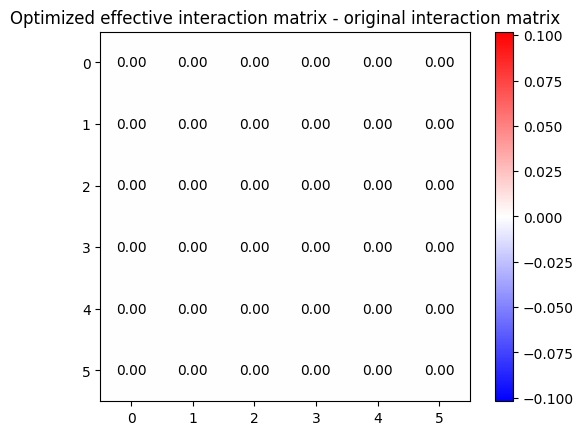

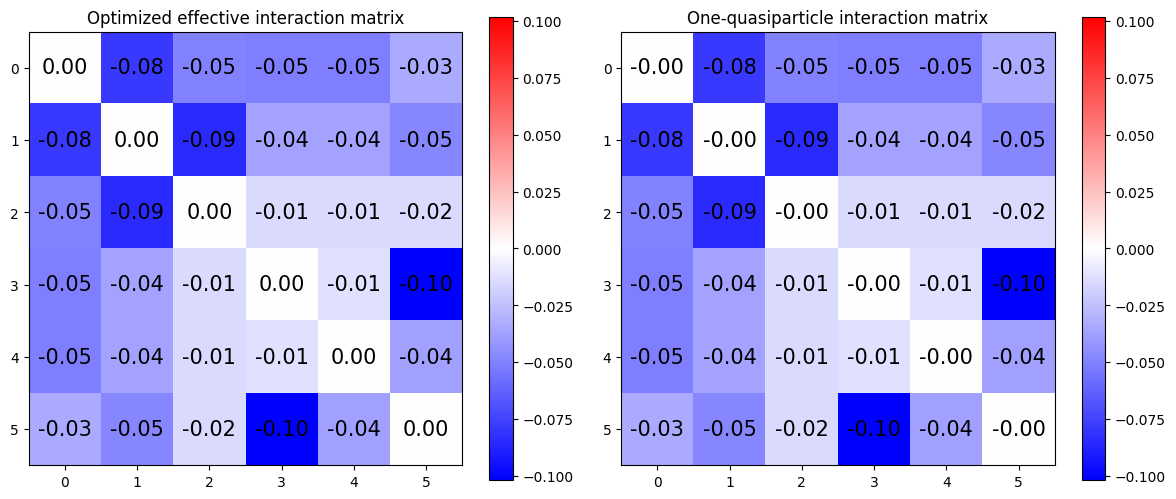

In [67]:
plt.imshow(
    g_corrected + g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(
            j,
            i,
            f"{g_corrected[i,j]+g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(np.abs(g_matrix))
matrices = [g_corrected, -1 * g_matrix]
titles = [
    "Optimized effective interaction matrix",
    "One-quasiparticle interaction matrix",
]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, cmap="bwr", vmin=-vmax, vmax=vmax)
    for i in range(n_qubits):
        for j in range(n_qubits):
            ax.text(
                j,
                i,
                f"{mat[i,j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=15,
            )
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Write the Diagonal part of the Ising Hamiltonian

Now, we have to write the full ising Hamiltonian that describes the constrain subspace, where our effective Hamiltonian acts, and then see how the spectrum behaves

#### First, we need to extract the self-energy from the single particle scenario.

To do so we build the self-energy of the single particle of the total Hamiltonian without longitudinal fields. Once that we extract these $\tilde{h}_a$ we can encode it in the $N_A N_B$ interactions

In [68]:
# get the total particle constrain
gamma = 100
ntot = 1

links = np.zeros(n_qubits)

coupling_dict = {}
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        if j != i + 1:
            coupling_dict[(i, j)] = 0.0
print(coupling_dict)
total_hamiltonian, _, _ = build_total_hamiltonian(
    n_qubits=n_qubits,
    d_opt=d_opt,
    gamma=gamma,
    links=links,
    coupling_dict=coupling_dict,
    ntot=ntot,
)

for i in range(basis.shape[0]):
    print(basis[i], total_hamiltonian[i, i])
#### then we can compute the self energy to remove it
new_hamiltonian, _, hamiltonian_delta, _, _ = build_effective_hamiltonian(
    total_hamiltonian=total_hamiltonian,
    basis=basis,
    gamma=gamma,
    low_energy_k=1,
    high_energy_k=[0, 2],
)

print("delta hamiltonian=", hamiltonian_delta * (gamma))


for i in range(diagonal_terms.shape[0]):
    for j in range(diagonal_terms.shape[0]):
        if i == j:
            links[i] = (
                hamiltonian_delta[-i - 1 + n_qubits, -j - 1 + n_qubits] * gamma
            )  # the interaction

print(links)
effective_longitudinal_field = diagonal_terms
total_hamiltonian, _, _ = build_total_hamiltonian(
    n_qubits=n_qubits,
    d_opt=d_opt,
    gamma=gamma,
    links=links + effective_longitudinal_field,
    coupling_dict=coupling_dict,
    ntot=ntot,
)

eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = (
    total_hamiltonian.eigenstates()
)
print(eigenvalues_total_hamiltonian * gamma)

{(0, 2): 0.0, (0, 3): 0.0, (0, 4): 0.0, (0, 5): 0.0, (1, 3): 0.0, (1, 4): 0.0, (1, 5): 0.0, (2, 4): 0.0, (2, 5): 0.0, (3, 5): 0.0}
[0 0 0 0 0 0] (100+0j)
[0 0 0 0 0 1] 0j
[0 0 0 0 1 0] 0j
[0 0 0 0 1 1] (100+0j)
[0 0 0 1 0 0] 0j
[0 0 0 1 0 1] (100+0j)
[0 0 0 1 1 0] (100+0j)
[0 0 0 1 1 1] (400+0j)
[0 0 1 0 0 0] 0j
[0 0 1 0 0 1] (100+0j)
[0 0 1 0 1 0] (100+0j)
[0 0 1 0 1 1] (400+0j)
[0 0 1 1 0 0] (100+0j)
[0 0 1 1 0 1] (400+0j)
[0 0 1 1 1 0] (400+0j)
[0 0 1 1 1 1] (900+0j)
[0 1 0 0 0 0] 0j
[0 1 0 0 0 1] (100+0j)
[0 1 0 0 1 0] (100+0j)
[0 1 0 0 1 1] (400+0j)
[0 1 0 1 0 0] (100+0j)
[0 1 0 1 0 1] (400+0j)
[0 1 0 1 1 0] (400+0j)
[0 1 0 1 1 1] (900+0j)
[0 1 1 0 0 0] (100+0j)
[0 1 1 0 0 1] (400+0j)
[0 1 1 0 1 0] (400+0j)
[0 1 1 0 1 1] (900+0j)
[0 1 1 1 0 0] (400+0j)
[0 1 1 1 0 1] (900+0j)
[0 1 1 1 1 0] (900+0j)
[0 1 1 1 1 1] (1600+0j)
[1 0 0 0 0 0] 0j
[1 0 0 0 0 1] (100+0j)
[1 0 0 0 1 0] (100+0j)
[1 0 0 0 1 1] (400+0j)
[1 0 0 1 0 0] (100+0j)
[1 0 0 1 0 1] (400+0j)
[1 0 0 1 1 0] (400+0j)
[1 0 0 

/tmp/ipykernel_123818/544688933.py:39: ComplexWarning: Casting complex values to real discards the imaginary part
  links[i] = (


This shift in the self-energy is fundamental to set only positive $N_A N_B$ interactions. Otherwise the two-body interaction would be attractive and therefore impossible to implement in Rydberg Platform

#### Build the Longitudinal Part of the Gadget related to the two-body encoding

First, we need to encode the two-body system using the first quantization encoding

In [69]:
n_qubits = 12
# get the computational basis of the space
basis = computational_basis(n_qubits)

In [128]:
#### particle constraint
gamma = 200
ntot = 1  # here we consider the first quantization encoding
# overall opposite sign for the quantum chemistry setting
effective_longitudinal_field = -1 * (diagonal_terms) / (gamma)

# lets start with the Z_A Z_B of the first particle constraint
hamiltonian_zz = 0.0
for i in range(n_qubits // 2):
    for j in range(i + 1, n_qubits // 2):
        hamiltonian_zz += SpinOperator(
            [("qz", i, "qz", j)],
            coupling=[(2 + c_matrix[i, j]) * gamma],
            size=n_qubits,
            verbose=1,
        ).qutip_op
# then the second particle constraint
for i in range(n_qubits // 2, n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_zz += SpinOperator(
            [("qz", i, "qz", j)],
            coupling=[(2 + c_matrix[i - n_qubits // 2, j - n_qubits // 2]) * gamma],
            size=n_qubits,
            verbose=1,
        ).qutip_op

# then the linear terms
hamiltonian_z = 0.0
# we split the constrain in the first particle sector and the second particle sector
for i in range(n_qubits // 2):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
        size=n_qubits,
        verbose=1,
    ).qutip_op
for i in range(n_qubits // 2, n_qubits):

    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[
            effective_longitudinal_field[i - n_qubits // 2] + gamma * (1 - 2 * ntot)
        ],
        size=n_qubits,
        verbose=1,
    ).qutip_op


# hardcore boson constrain -> it forces the state to avoid 2 particles in the same site
gamma2 = gamma
for i in range(n_qubits // 2):
    hamiltonian_z += SpinOperator(
        [("qz", i, "qz", i + n_qubits // 2)],
        coupling=[gamma2],
        size=n_qubits,
        verbose=1,
    ).qutip_op

# we need to add the two-body interaction removing the self energy contribution
for i in range(n_qubits // 2):
    for j in range(n_qubits // 2):
        if i != j:
            coupling = -0.5 * g_twobody[(np.min([i, j]), np.max([i, j]))] / gamma

            # A_i × B_j
            hamiltonian_zz += SpinOperator(
                [("qz", i, "qz", j + n_qubits // 2)], coupling=[coupling], size=n_qubits
            ).qutip_op

            # A_j × B_i  (the missing symmetric term)
            hamiltonian_zz += SpinOperator(
                [("qz", i + n_qubits // 2, "qz", j)], coupling=[coupling], size=n_qubits
            ).qutip_op

            print(
                i, j, g_twobody[(np.min([i, j]), np.max([i, j]))] + links[i] + links[j]
            )
            print(i, j, "\n")
# finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

longitudinal_hamiltonian = (
    hamiltonian_zz + hamiltonian_z + 2 * gamma * (ntot**2) * identity_qubit_space
)

0 1 1.2881044068892153
0 1 

0 2 1.4299503197418144
0 2 

0 3 1.4480879856209408
0 3 

0 4 1.448087985620941
0 4 

0 5 1.4757354538567538
0 5 

1 0 1.2881044068892153
1 0 

1 2 1.3334489711955595
1 2 

1 3 1.3763029560950435
1 3 

1 4 1.3763029560950437
1 4 

1 5 1.3863949607502244
1 5 

2 0 1.4299503197418144
2 0 

2 1 1.3334489711955595
2 1 

2 3 1.4397958116223535
2 3 

2 4 1.439795811622354
2 4 

2 5 1.46032707815236
2 5 

3 0 1.4480879856209408
3 0 

3 1 1.3763029560950435
3 1 

3 2 1.4397958116223535
3 2 

3 4 1.4401256205103945
3 4 

3 5 1.3519958853527374
3 5 

4 0 1.448087985620941
4 0 

4 1 1.3763029560950437
4 1 

4 2 1.439795811622354
4 2 

4 3 1.4401256205103945
4 3 

4 5 1.4239566428208321
4 5 

5 0 1.4757354538567538
5 0 

5 1 1.3863949607502244
5 1 

5 2 1.46032707815236
5 2 

5 3 1.3519958853527374
5 3 

5 4 1.4239566428208321
5 4 



#### Representation of the diagonal part of the Ising Hamiltonian

In [129]:
diagonal_energies = longitudinal_hamiltonian.diag()

for i, b in enumerate(basis):
    if np.sum(b[: n_qubits // 2]) == 1 and np.sum(b[n_qubits // 2 :]) == 1:
        print(b, diagonal_energies[i])

print("\n")
for i, b in enumerate(basis):
    if np.abs(diagonal_energies[i]) < 10**-1:
        print(b, diagonal_energies[i])

[0 0 0 0 0 1 0 0 0 0 0 1] 200.01416038002003
[0 0 0 0 0 1 0 0 0 0 1 0] 0.009347989574450821
[0 0 0 0 0 1 0 0 0 1 0 0] 0.009707793361769745
[0 0 0 0 0 1 0 0 1 0 0 0] 0.00913232423243926
[0 0 0 0 0 1 0 1 0 0 0 0] 0.009896655653790276
[0 0 0 0 0 1 1 0 0 0 0 0] 0.01123253550173331
[0 0 0 0 1 0 0 0 0 0 0 1] 0.009347989574450821
[0 0 0 0 1 0 0 0 0 0 1 0] 200.01592407433634
[0 0 0 0 1 0 0 0 0 1 0 0] 0.010148991844118882
[0 0 0 0 1 0 0 0 1 0 0 0] 0.010116827723265942
[0 0 0 0 1 0 0 1 0 0 0 0] 0.010828962835205402
[0 0 0 0 1 0 1 0 0 0 0 0] 0.01225262000099292
[0 0 0 1 0 0 0 0 0 0 0 1] 0.009707793361769745
[0 0 0 1 0 0 0 0 0 0 1 0] 0.010148991844118882
[0 0 0 1 0 0 0 0 0 1 0 0] 200.01592407433634
[0 0 0 1 0 0 0 0 1 0 0 0] 0.010116827723265942
[0 0 0 1 0 0 0 1 0 0 0 0] 0.010828962835205402
[0 0 0 1 0 0 1 0 0 0 0 0] 0.01225262000099292
[0 0 1 0 0 0 0 0 0 0 0 1] 0.00913232423243926
[0 0 1 0 0 0 0 0 0 0 1 0] 0.010116827723265942
[0 0 1 0 0 0 0 0 0 1 0 0] 0.010116827723265942
[0 0 1 0 0 0 0 0 1 0 0 0

### Part of the second step is to introduce the transverse field term

In [130]:
# the transverse field
transverse_hamiltonian = 0.0
for i in range(n_qubits // 2):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    transverse_hamiltonian += SpinOperator(
        [("x", i)], coupling=[d_opt[i] / np.sqrt(2)], size=n_qubits, verbose=1
    ).qutip_op
for i in range(n_qubits // 2, n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    transverse_hamiltonian += SpinOperator(
        [("x", i)],
        coupling=[d_opt[i - n_qubits // 2] / np.sqrt(2)],
        size=n_qubits,
        verbose=1,
    ).qutip_op

#### Compute the spectrum of the full Hamiltonian

Once that we compute the spectrum, we expect that our ground state lies in the subspace near the $E_0=0$ region, Let's see what we get

In [131]:
total_hamiltonian = longitudinal_hamiltonian + transverse_hamiltonian
eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = (
    total_hamiltonian.eigenstates(eigvals=40)
)

#### Check the structure of the effective Hamiltonian to control the longitudinal couplings $g_{AA}$

In [132]:
idx_eigval = 0
for r, eigenstate in enumerate(eigenstates_total_hamiltonian):

    psi = eigenstate.full().flatten()
    n_value = compute_particle_number(psi, basis)
    if np.abs(n_value - 2) < 10**-2:
        print(eigenvalues_total_hamiltonian[r] * gamma - energy_shift)
        idx_eigval = r
print("idx_eigval=", idx_eigval)
value = 0.0
p_twobody = {}
psi_twobody = {}
counts = {}
for r, psi_component in enumerate(
    eigenstates_total_hamiltonian[idx_eigval - 1].full().flatten()
):
    if np.sum(basis[r]) == 2:
        idxs = np.nonzero(basis[r])[0]
        a, b = idxs
        idxs = tuple(sorted((a % (n_qubits // 2), b % (n_qubits // 2))))
        value += psi_component**2
        p_twobody[tuple(idxs)] = p_twobody.get(tuple(idxs), 0) + psi_component**2
        psi_twobody[tuple(idxs)] = psi_twobody.get(tuple(idxs), 0) + (psi_component)
        counts[tuple(idxs)] = counts.get(tuple(idxs), 0) + 1
        # step 1: collect all amplitudes mapping to the same logical pair
        print(psi_component, basis[r], np.sum(basis[r]), idxs, counts[tuple(idxs)])

# step 2: normalize for the number of occurrences of each logical pair
psi_twobody = {k: v / np.sqrt(counts[k] // 2) for k, v in psi_twobody.items()}
p_twobody_exact = {}
psi_twobody_exact = {}
for r, psi_component in enumerate(eigenstates_particle_conserved[:, 0]):

    idxs = np.nonzero(HBB.basis[r])[0]
    p_twobody_exact[tuple(idxs)] = (
        p_twobody_exact.get(tuple(idxs), 0) + psi_component**2
    )
    psi_twobody_exact[tuple(idxs)] = (
        psi_twobody_exact.get(tuple(idxs), 0) + psi_component
    )

27.396845164729612
27.426453997029054
27.527994152863695
27.539742867593496
27.65723471488172
27.669745806165754
27.681455485254794
27.697846817395103
27.714638472861925
27.71731084598686
27.791530467183048
27.792381108538102
27.82558373426507
27.83644441507083
27.939342519857345
27.943887890691283
27.94645074669565
27.95662762179952
27.97262863690292
27.975768613556415
27.997891286262302
28.019820888410756
28.20226957213898
28.2236871290795
28.259227135518373
28.26517567827381
28.27056918910913
28.272585316917667
28.502904811049746
28.51314285164393
idx_eigval= 29
(-1.3202421050850788e-07+0j) [0 0 0 0 0 0 0 0 0 0 1 1] 2 (np.int64(4), np.int64(5)) 1
(-3.0770250926404064e-07+0j) [0 0 0 0 0 0 0 0 0 1 0 1] 2 (np.int64(3), np.int64(5)) 1
(-8.331429587893346e-09+0j) [0 0 0 0 0 0 0 0 0 1 1 0] 2 (np.int64(3), np.int64(4)) 1
(-2.3124955339515196e-08+0j) [0 0 0 0 0 0 0 0 1 0 0 1] 2 (np.int64(2), np.int64(5)) 1
(-2.5255805024583522e-08+0j) [0 0 0 0 0 0 0 0 1 0 1 0] 2 (np.int64(2), np.int64(4)) 1

/tmp/ipykernel_123818/2048804685.py:29: RuntimeWarning: divide by zero encountered in scalar divide
  psi_twobody = {k: v / np.sqrt(counts[k] // 2) for k, v in psi_twobody.items()}
/tmp/ipykernel_123818/2048804685.py:29: RuntimeWarning: invalid value encountered in scalar divide
  psi_twobody = {k: v / np.sqrt(counts[k] // 2) for k, v in psi_twobody.items()}


##### We compare the probability distributions

In [133]:
for key in p_twobody_exact.keys():
    print(key, p_twobody_exact[key], p_twobody.get(key, 0))
print("\n")
fidelity = 0.0
fidelity = 0.0
overlap = 0.0
for key in psi_twobody_exact.keys():
    overlap += np.conj(psi_twobody_exact[key]) * psi_twobody.get(key, 0)
    print(
        psi_twobody_exact[key],
        psi_twobody.get(key, 0),
        np.conj(psi_twobody_exact[key]) * psi_twobody.get(key, 0),
    )
fidelity = np.abs(overlap) ** 2
print("Fidelity:", fidelity)

(np.int64(0), np.int64(1)) [[0.8834986]] (0.9019035491118685+0j)
(np.int64(0), np.int64(2)) [[0.08331937]] (0.06722591023974009+0j)
(np.int64(0), np.int64(3)) [[0.00454499]] (0.0037236392790310096+0j)
(np.int64(0), np.int64(4)) [[0.00688152]] (0.007830344283345817+0j)
(np.int64(0), np.int64(5)) [[0.00416388]] (0.0033501674043987404+0j)
(np.int64(1), np.int64(2)) [[0.00216945]] (0.00290227459179703+0j)
(np.int64(1), np.int64(3)) [[0.00583915]] (0.004943361288172301+0j)
(np.int64(1), np.int64(4)) [[0.00593395]] (0.005221964769276765+0j)
(np.int64(1), np.int64(5)) [[0.00050497]] (0.0005213559899031238+0j)
(np.int64(2), np.int64(3)) [[0.00117355]] (0.0008260441440563457+0j)
(np.int64(2), np.int64(4)) [[0.00134623]] (0.0010157067762996065+0j)
(np.int64(2), np.int64(5)) [[0.00017297]] (0.00014530178711823037+0j)
(np.int64(3), np.int64(4)) [[0.00023932]] (0.00019138092477551615+0j)
(np.int64(3), np.int64(5)) [[0.00012136]] (0.00011578122048563692+0j)
(np.int64(4), np.int64(5)) [[9.06852687e-0

##### State preparation with the interaction

In [100]:
from tqdm import tqdm

psi = np.zeros(basis.shape[0])
psi[2 ** (n_qubits - 1)] = 1  # initialize at [1,0,0,0,0]
print(basis[2 ** (n_qubits - 1)])
psi_init = psi.copy()
total_hamiltonian_scipy = total_hamiltonian.data.as_scipy()

time_simulated = np.linspace(0, 10 * gamma, int(gamma))
delta_t = time_simulated[1] - time_simulated[0]
fidelity_simulated = []
tbar = tqdm(enumerate(time_simulated))
for i, t in tbar:
    psi = expm_multiply(-1j * delta_t * total_hamiltonian_scipy, psi)
    fidelity_simulated.append(
        psi.conj().dot(psi_init) * (psi.conj().dot(psi_init)).conj()
    )

[1 0 0 0 0 0 0 0 0 0 0 0]


0it [00:06, ?it/s]


KeyboardInterrupt: 

In [ ]:
plt.plot(time_simulated / gamma, fidelity_simulated)
plt.plot(time, fidelity_loc)
plt.show()

In [ ]:
plt.bar(np.arange(basis.shape[0]), psi.conj() * psi)
plt.xticks(np.arange(basis.shape[0]), basis, rotation=90)
plt.show()

In [ ]:
import matplotlib.animation as animation
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

# ── 1. Time evolution: collect n_i(t) ────────────────────────────────────────
psi = np.zeros(basis.shape[0], dtype=complex)
psi[1] = 1.0  # particle at site 0: |10000⟩

total_hamiltonian_scipy = total_hamiltonian.data.as_scipy()

time_simulated = np.linspace(0, 10 * gamma, int(50 * gamma))
delta_t = time_simulated[1] - time_simulated[0]

# n_data[frame, site] = <n_i>(t)
n_data = np.zeros((len(time_simulated), n_qubits))

for frame in range(len(time_simulated)):
    psi = expm_multiply(-1j * delta_t * total_hamiltonian_scipy, psi)
    prob = (psi.conj() * psi).real  # |ψ_s|², shape (2**n_qubits,)
    n_data[frame] = prob @ basis  # <n_i> = Σ_s |ψ_s|² * basis[s,i]

# ── 2. Build weighted graph (ZZ couplings as edge weights) ────────────────────
# Constraint term (+2γ) is present for ALL pairs.
# coupling_dict adds its contribution on top (×γ inside build_total_hamiltonian).
G_anim = nx.Graph()
G_anim.add_nodes_from(range(n_qubits))

edge_weights = {}
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        w = 2 * gamma  # constraint (all pairs)
        key = (
            (i, j)
            if (i, j) in coupling_dict
            else (j, i) if (j, i) in coupling_dict else None
        )
        if key is not None:
            w += coupling_dict[key] * gamma  # coupling_dict contribution
        G_anim.add_edge(i, j, weight=w)
        edge_weights[(i, j)] = w

pos_anim = nx.circular_layout(G_anim)

pos_edges = [(i, j) for (i, j), w in edge_weights.items() if w >= 0]
neg_edges = [(i, j) for (i, j), w in edge_weights.items() if w < 0]
max_w = max(abs(w) for w in edge_weights.values()) or 1.0
pos_widths = [4 * abs(edge_weights[e]) / max_w for e in pos_edges]
neg_widths = [4 * abs(edge_weights[e]) / max_w for e in neg_edges]

# ── 3. Build figure ───────────────────────────────────────────────────────────
fig, (ax_g, ax_l) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(r"Single-particle dynamics — $\langle n_i \rangle(t)$", fontsize=13)

cmap = plt.cm.plasma
norm = Normalize(vmin=0, vmax=1)

# fixed edges (drawn once)
nx.draw_networkx_edges(
    G_anim,
    pos_anim,
    edgelist=pos_edges,
    width=pos_widths,
    edge_color="steelblue",
    alpha=0.7,
    ax=ax_g,
)
nx.draw_networkx_edges(
    G_anim,
    pos_anim,
    edgelist=neg_edges,
    width=neg_widths,
    edge_color="tomato",
    alpha=0.7,
    ax=ax_g,
    style="dashed",
)

# animated nodes
nodes = nx.draw_networkx_nodes(
    G_anim,
    pos_anim,
    ax=ax_g,
    node_color=n_data[0],
    cmap=cmap,
    vmin=0,
    vmax=1,
    node_size=900,
)
nx.draw_networkx_labels(G_anim, pos_anim, ax=ax_g, font_color="white", font_size=11)
ax_g.axis("off")
plt.colorbar(
    ScalarMappable(norm=norm, cmap=cmap), ax=ax_g, label=r"$\langle n_i \rangle$"
)
ax_g.legend(
    handles=[
        Line2D([0], [0], color="steelblue", lw=2, label=rf"$+2\gamma$ (NN)"),
        Line2D(
            [0], [0], color="tomato", lw=2, ls="--", label=rf"$-0.01\gamma$ (non-NN)"
        ),
    ],
    loc="upper right",
    fontsize=9,
)

# time-series panel
t_over_gamma = time_simulated / gamma
ts_lines = [ax_l.plot([], [], label=f"site {i}")[0] for i in range(n_qubits)]
vline = ax_l.axvline(0, color="k", lw=1, ls="--")
ax_l.set_xlim(0, t_over_gamma[-1])
ax_l.set_ylim(-0.05, 1.05)
ax_l.set_xlabel(r"$t\,/\,\gamma$", fontsize=12)
ax_l.set_ylabel(r"$\langle n_i \rangle$", fontsize=12)
ax_l.legend(fontsize=9, loc="upper right")
ax_l.set_title("Occupation vs time")


# ── 4. Animation ──────────────────────────────────────────────────────────────
def init():
    nodes.set_array(n_data[0])
    for l in ts_lines:
        l.set_data([], [])
    return [nodes, vline] + ts_lines


def update(f):
    nodes.set_array(n_data[f])
    ax_g.set_title(rf"$t\,/\,\gamma = {t_over_gamma[f]:.2f}$")
    for i, l in enumerate(ts_lines):
        l.set_data(t_over_gamma[: f + 1], n_data[: f + 1, i])
    vline.set_xdata([t_over_gamma[f]])
    return [nodes, vline] + ts_lines


stride = max(1, len(time_simulated) // 300)  # keep ~300 frames in the video
ani = animation.FuncAnimation(
    fig,
    update,
    frames=range(0, len(time_simulated), stride),
    init_func=init,
    interval=30,
    blit=True,
)

ani.save("edge_state.mp4", writer="ffmpeg", fps=30, dpi=150)
print("Saved  →  dynamics_1d_chain.mp4")
plt.show()

#### Adiabatic State Preparation

We divide the initialization of the total hamiltonian, since the driver is just the 0-th component of the Z hamiltonian. We just need to tune the initialization of the other components

In [ ]:
# get the total particle constrain
gamma = 50
ntot = 1
links = np.zeros(n_qubits)

total_hamiltonian, longitudinal_hamiltonian, _ = build_total_hamiltonian(
    n_qubits=n_qubits,
    d_opt=d_opt,
    gamma=gamma,
    links=links,
    coupling_dict=coupling_dict,
    ntot=ntot,
)

new_hamiltonian, _, hamiltonian_delta, _, _ = build_effective_hamiltonian(
    total_hamiltonian=total_hamiltonian,
    basis=basis,
    gamma=gamma,
    low_energy_k=1,
    high_energy_k=[0, 2],
)

links = new_hamiltonian.diagonal() * gamma

total_hamiltonian, longitudinal_hamiltonian, _ = build_total_hamiltonian(
    n_qubits=n_qubits,
    d_opt=d_opt,
    gamma=gamma,
    links=links,
    coupling_dict=coupling_dict,
    ntot=ntot,
)

Then the driver Hamiltonian

In [ ]:
# get the total particle constrain
ntot = 1
# we define the effective longitudianl field that contributes to the driver hamiltonian hamiltonian of Be 6
external_field = np.zeros(diagonal_elements.shape[0])
external_field = -1 / d_opt[0] ** 2
print(external_field, links)

_, driver_hamiltonian, _ = build_total_hamiltonian(
    n_qubits=n_qubits,
    d_opt=d_opt,
    gamma=gamma,
    links=links + external_field,
    coupling_dict=coupling_dict,
    ntot=ntot,
)


print(driver_hamiltonian.diag())
print(basis)

Then we get the state preparation, initializing the state and evolving the interpolate hamiltonian

In [ ]:
driver_hamiltonian_sparse = driver_hamiltonian.data.as_scipy()
_, psi = eigsh(driver_hamiltonian_sparse, k=25, which="SA")
psi = psi[:, 17]

print(psi.conj().T @ driver_hamiltonian_sparse @ psi)
plt.bar(np.arange(basis.shape[0]), psi.conj() * psi)

plt.xticks(np.arange(basis.shape[0]), basis, rotation=90)
plt.show()

Time evolution

In [ ]:
#### Initialize the state and convert the hamiltonians
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply

total_hamiltonian_sparse = total_hamiltonian.data.as_scipy()

plt.bar(np.arange(basis.shape[0]), psi.conj() * psi)
plt.xticks(np.arange(basis.shape[0]), basis, rotation=90)
plt.show()

print(psi.conj().T @ driver_hamiltonian_sparse @ psi)

#### start the time evolution

nlevels = 20
tau = 100
time_steps = int(10 * tau)
time = np.linspace(0, tau, time_steps)
delta_t = time[1] - time[0]
spectrum = np.zeros((time_steps, nlevels))
energy = np.zeros(time_steps)
for i, t in enumerate(time):
    hamiltonian_t_sparse = (1 - t / tau) * driver_hamiltonian_sparse + (
        t / tau
    ) * total_hamiltonian_sparse
    psi = expm_multiply(-1j * delta_t * hamiltonian_t_sparse, psi)
    eigenvalues, eigenvectors = eigsh(hamiltonian_t_sparse, k=nlevels, which="SA")
    idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    spectrum[i] = eigenvalues
    energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))
print("final energy=", psi.conj().dot(total_hamiltonian_sparse.dot(psi)))

Results of the QA state preparation

In [ ]:
plt.bar(np.arange(basis.shape[0]), psi.conj() * psi)
plt.xticks(np.arange(basis.shape[0]), basis, rotation=90)
plt.show()

In [ ]:
print(eigenvalues_total_hamiltonian)

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(time, spectrum, linewidth=4)
plt.plot(time, energy, linestyle="--")
psi_qutip = array_to_qutip(psi, n_qubits)
f_value = fidelity(psi_qutip, eigenstates_tb[0])
print("fidelity=", fidelity(psi_qutip, eigenstates_tb[0]), eigenvalues_tb[0])
plt.text(
    x=10,
    y=-0.3,
    s=r"$F=$" + f"{f_value:.3f} " + r"$\gamma=$" + f"{gamma:.0f}J",
    fontsize=30,
)
plt.xlabel(r"$tJ$", fontsize=30)
plt.ylabel(r"$e_i$", fontsize=30)
plt.legend(fontsize=20)
plt.ylim([-0.1, 0.1])
plt.tick_params(which="major", labelsize=15)
plt.show()

print(energy[-1] * gamma)

#### Robstness of the Gadget vs $\gamma$

We study the robustness of the Gadget Hamiltonian tuning the $\gamma$ parameter, to check if we can reduce it to comparable values

In [ ]:
from qutip import fidelity

gammas = np.linspace(1, 200, 40)
energy_error = []
fidelities = []
for gamma in gammas:
    # get the total particle constrain
    ntot = 1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field = ((d_opt**2)) / (gamma)

    # lets start with the Z_A Z_B of the constrain
    hamiltonian_zz = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz += SpinOperator(
                [("qz", i, "qz", j)], coupling=[2 * gamma], size=n_qubits, verbose=1
            ).qutip_op

    #### constrain related to the tunable effective energy
    hamiltonian_zz += SpinOperator(
        [("qz", 0, "qz", 2)], coupling=[-2 * gamma], size=n_qubits, verbose=1
    ).qutip_op
    hamiltonian_zz += SpinOperator(
        [("qz", 1, "qz", 3)], coupling=[-2 * gamma], size=n_qubits, verbose=1
    ).qutip_op

    # then the linear terms
    hamiltonian_z = 0.0
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    # finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian = (
        hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
    )
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        total_hamiltonian += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
        ).qutip_op

    eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = (
        total_hamiltonian.eigenstates()
    )
    print(
        eigenvalues_total_hamiltonian[2] * gamma,
        value[0],
    )
    energy_error.append(
        np.abs(eigenvalues_total_hamiltonian[2] * gamma - value[0]) / np.abs(value[0])
    )
    print(
        "fidelities=",
        qt.fidelity(eigenstates_total_hamiltonian[2], eigenstates_tb[gs_idx]),
        "\n",
    )
    fidelities.append(
        qt.fidelity(eigenstates_total_hamiltonian[2], eigenstates_tb[gs_idx])
    )

In [ ]:
plt.plot(gammas, energy_error, linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel("Gadget Relative Error", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(gammas, 1 - np.array(fidelities), linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel(r"$1-F_{\text{Gadget}}$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

#### What about the state preparation using QA then ??

In [ ]:
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply

fidelities = []
energy_error = []
gammas = np.linspace(1, 50, 10)
for gamma in gammas:
    # get the total particle constrain
    ntot = 1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum()) / (
        gamma
    )

    # lets start with the Z_A Z_B of the constrain
    hamiltonian_zz = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz += SpinOperator(
                [("qz", i, "qz", j)], coupling=[2 * gamma], size=n_qubits, verbose=1
            ).qutip_op

    # then the linear terms
    hamiltonian_z = 0.0
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    # finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian = (
        hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
    )
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        total_hamiltonian += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
        ).qutip_op
    #### Initialize the state and convert the hamiltonians

    total_hamiltonian_sparse = total_hamiltonian.data.as_scipy()
    driver_hamiltonian_sparse = driver_hamiltonian.data.as_scipy()
    # initialize the state
    psi = np.zeros(basis.shape[0])
    psi[idx_init] = 1.0

    #### start the time evolution

    nlevels = 3
    tau = 10 * gamma
    time_steps = int(10 * tau)
    time = np.linspace(0, tau, time_steps)
    delta_t = time[1] - time[0]
    spectrum = np.zeros((time_steps, nlevels))
    energy = np.zeros(time_steps)
    for i, t in enumerate(time):
        hamiltonian_t_sparse = (1 - t / tau) * driver_hamiltonian_sparse + (
            t / tau
        ) * total_hamiltonian_sparse
        psi = expm_multiply(-1j * delta_t * hamiltonian_t_sparse, psi)
        eigenvalues, eigenvectors = eigsh(hamiltonian_t_sparse, k=nlevels, which="SA")
        idx = np.argsort(eigenvalues)
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        spectrum[i] = eigenvalues
        energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))
    psi_qutip = array_to_qutip(psi, n_qubits)
    energy_error.append(np.abs(energy[-1] * gamma - value[0]) / np.abs(value[0]))
    f_value = fidelity(psi_qutip, eigenstates_total_hamiltonian[0])
    fidelities.append(f_value)
    print(gamma)
    print("energy=", energy[-1] * gamma)
    print("fidelity=", fidelity(psi_qutip, eigenstates_total_hamiltonian[0]))

In [ ]:
plt.plot(gammas, energy_error, linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel(r"$|\Delta_r e|$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(gammas, 1 - np.array(fidelities), linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel(r"$1-F(\tau^* \gamma J^{-1} )$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()